测试数据和训练数据分组，数据分batch

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.metrics import accuracy_score
from joblib import load

# 设备配置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 数据加载和预处理
class BearingDataset(Dataset):
    def __init__(self, dataframe):
        self.data = dataframe.iloc[:, :-1].values.astype(np.float32)
        self.labels = dataframe.iloc[:, -1].values.astype(np.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx], dtype=torch.float32).unsqueeze(-1)  # (seq_len, 1)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

# 加载保存的数据集
train_df = load('train_set')
val_df = load('val_set')
test_df = load('test_set')

# 创建DataLoader
batch_size = 32
train_dataset = BearingDataset(train_df)
val_dataset = BearingDataset(val_df)
test_dataset = BearingDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# 2. Transformer模型定义
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1024):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransformerClassifier(nn.Module):
    def __init__(self, input_dim=1, d_model=32, nhead=4, 
                 num_layers=3, dim_feedforward=128, num_classes=10):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_len, 1)
        x = self.embedding(x)  # (batch_size, seq_len, d_model)
        x = self.pos_encoder(x)
        x = x.permute(1, 0, 2)  # (seq_len, batch_size, d_model)
        output = self.transformer(x)  # (seq_len, batch_size, d_model)
        output = output.mean(dim=0)  # (batch_size, d_model)
        return self.fc(output)

# 3. 模型初始化
model = TransformerClassifier(
    d_model=64,
    nhead=2,
    num_layers=3,
    dim_feedforward=128,
    num_classes=10
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)

# 4. 训练和验证函数
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * inputs.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), accuracy

# 5. 训练循环
best_val_acc = 0.0
patience_counter = 0
patience = 10

for epoch in range(100):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    scheduler.step(val_acc)
    
    print(f"Epoch {epoch+1:03d} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")
    
    # 早停机制
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping!")
            break

# 6. 测试最佳模型
model.load_state_dict(torch.load("best_model.pth"))
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"\nFinal Test Performance: | Test Acc: {test_acc:.4f}")

C:\Users\13911\AppData\Local\Temp\ipykernel_30096\3035492889.py:15: DeprecationWarning: `np.long` is a deprecated alias for `np.compat.long`. To silence this warning, use `np.compat.long` by itself. In the likely event your code does not need to work on Python 2 you can use the builtin `int` for which `np.compat.long` is itself an alias. Doing this will not modify any behaviour and is safe. When replacing `np.long`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  self.labels = dataframe.iloc[:, -1].values.astype(np.long)
d:\software\Anaconda3\envs\pyg38\lib\site-packages\torch\nn\modules\transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(u

KeyboardInterrupt: 

C:\Users\13911\AppData\Local\Temp\ipykernel_36820\2627884266.py:21: DeprecationWarning: `np.long` is a deprecated alias for `np.compat.long`. To silence this warning, use `np.compat.long` by itself. In the likely event your code does not need to work on Python 2 you can use the builtin `int` for which `np.compat.long` is itself an alias. Doing this will not modify any behaviour and is safe. When replacing `np.long`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  self.labels = dataframe.iloc[:, -1].values.astype(np.long)
d:\software\Anaconda3\envs\pyg38\lib\site-packages\torch\nn\modules\transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(u

Epoch 001 | Train Loss: 2.3109 | Train Acc: 0.1104 | Val Loss: 2.2702 | Val Acc: 0.0773
Epoch 002 | Train Loss: 2.1324 | Train Acc: 0.1956 | Val Loss: 1.9125 | Val Acc: 0.2232
Epoch 003 | Train Loss: 1.8099 | Train Acc: 0.3084 | Val Loss: 1.6995 | Val Acc: 0.3712
Epoch 004 | Train Loss: 1.6756 | Train Acc: 0.3685 | Val Loss: 1.5998 | Val Acc: 0.4421
Epoch 005 | Train Loss: 1.5650 | Train Acc: 0.4739 | Val Loss: 1.4638 | Val Acc: 0.4742
Epoch 006 | Train Loss: 1.3951 | Train Acc: 0.4666 | Val Loss: 1.2872 | Val Acc: 0.4979
Epoch 007 | Train Loss: 1.2750 | Train Acc: 0.5015 | Val Loss: 1.1997 | Val Acc: 0.5193
Epoch 008 | Train Loss: 1.2149 | Train Acc: 0.5340 | Val Loss: 1.1433 | Val Acc: 0.5451
Epoch 009 | Train Loss: 1.1700 | Train Acc: 0.5402 | Val Loss: 1.1117 | Val Acc: 0.5601
Epoch 010 | Train Loss: 1.1357 | Train Acc: 0.5739 | Val Loss: 1.0773 | Val Acc: 0.6052
Epoch 011 | Train Loss: 1.1045 | Train Acc: 0.6039 | Val Loss: 1.0690 | Val Acc: 0.6459
Epoch 012 | Train Loss: 1.0689 |

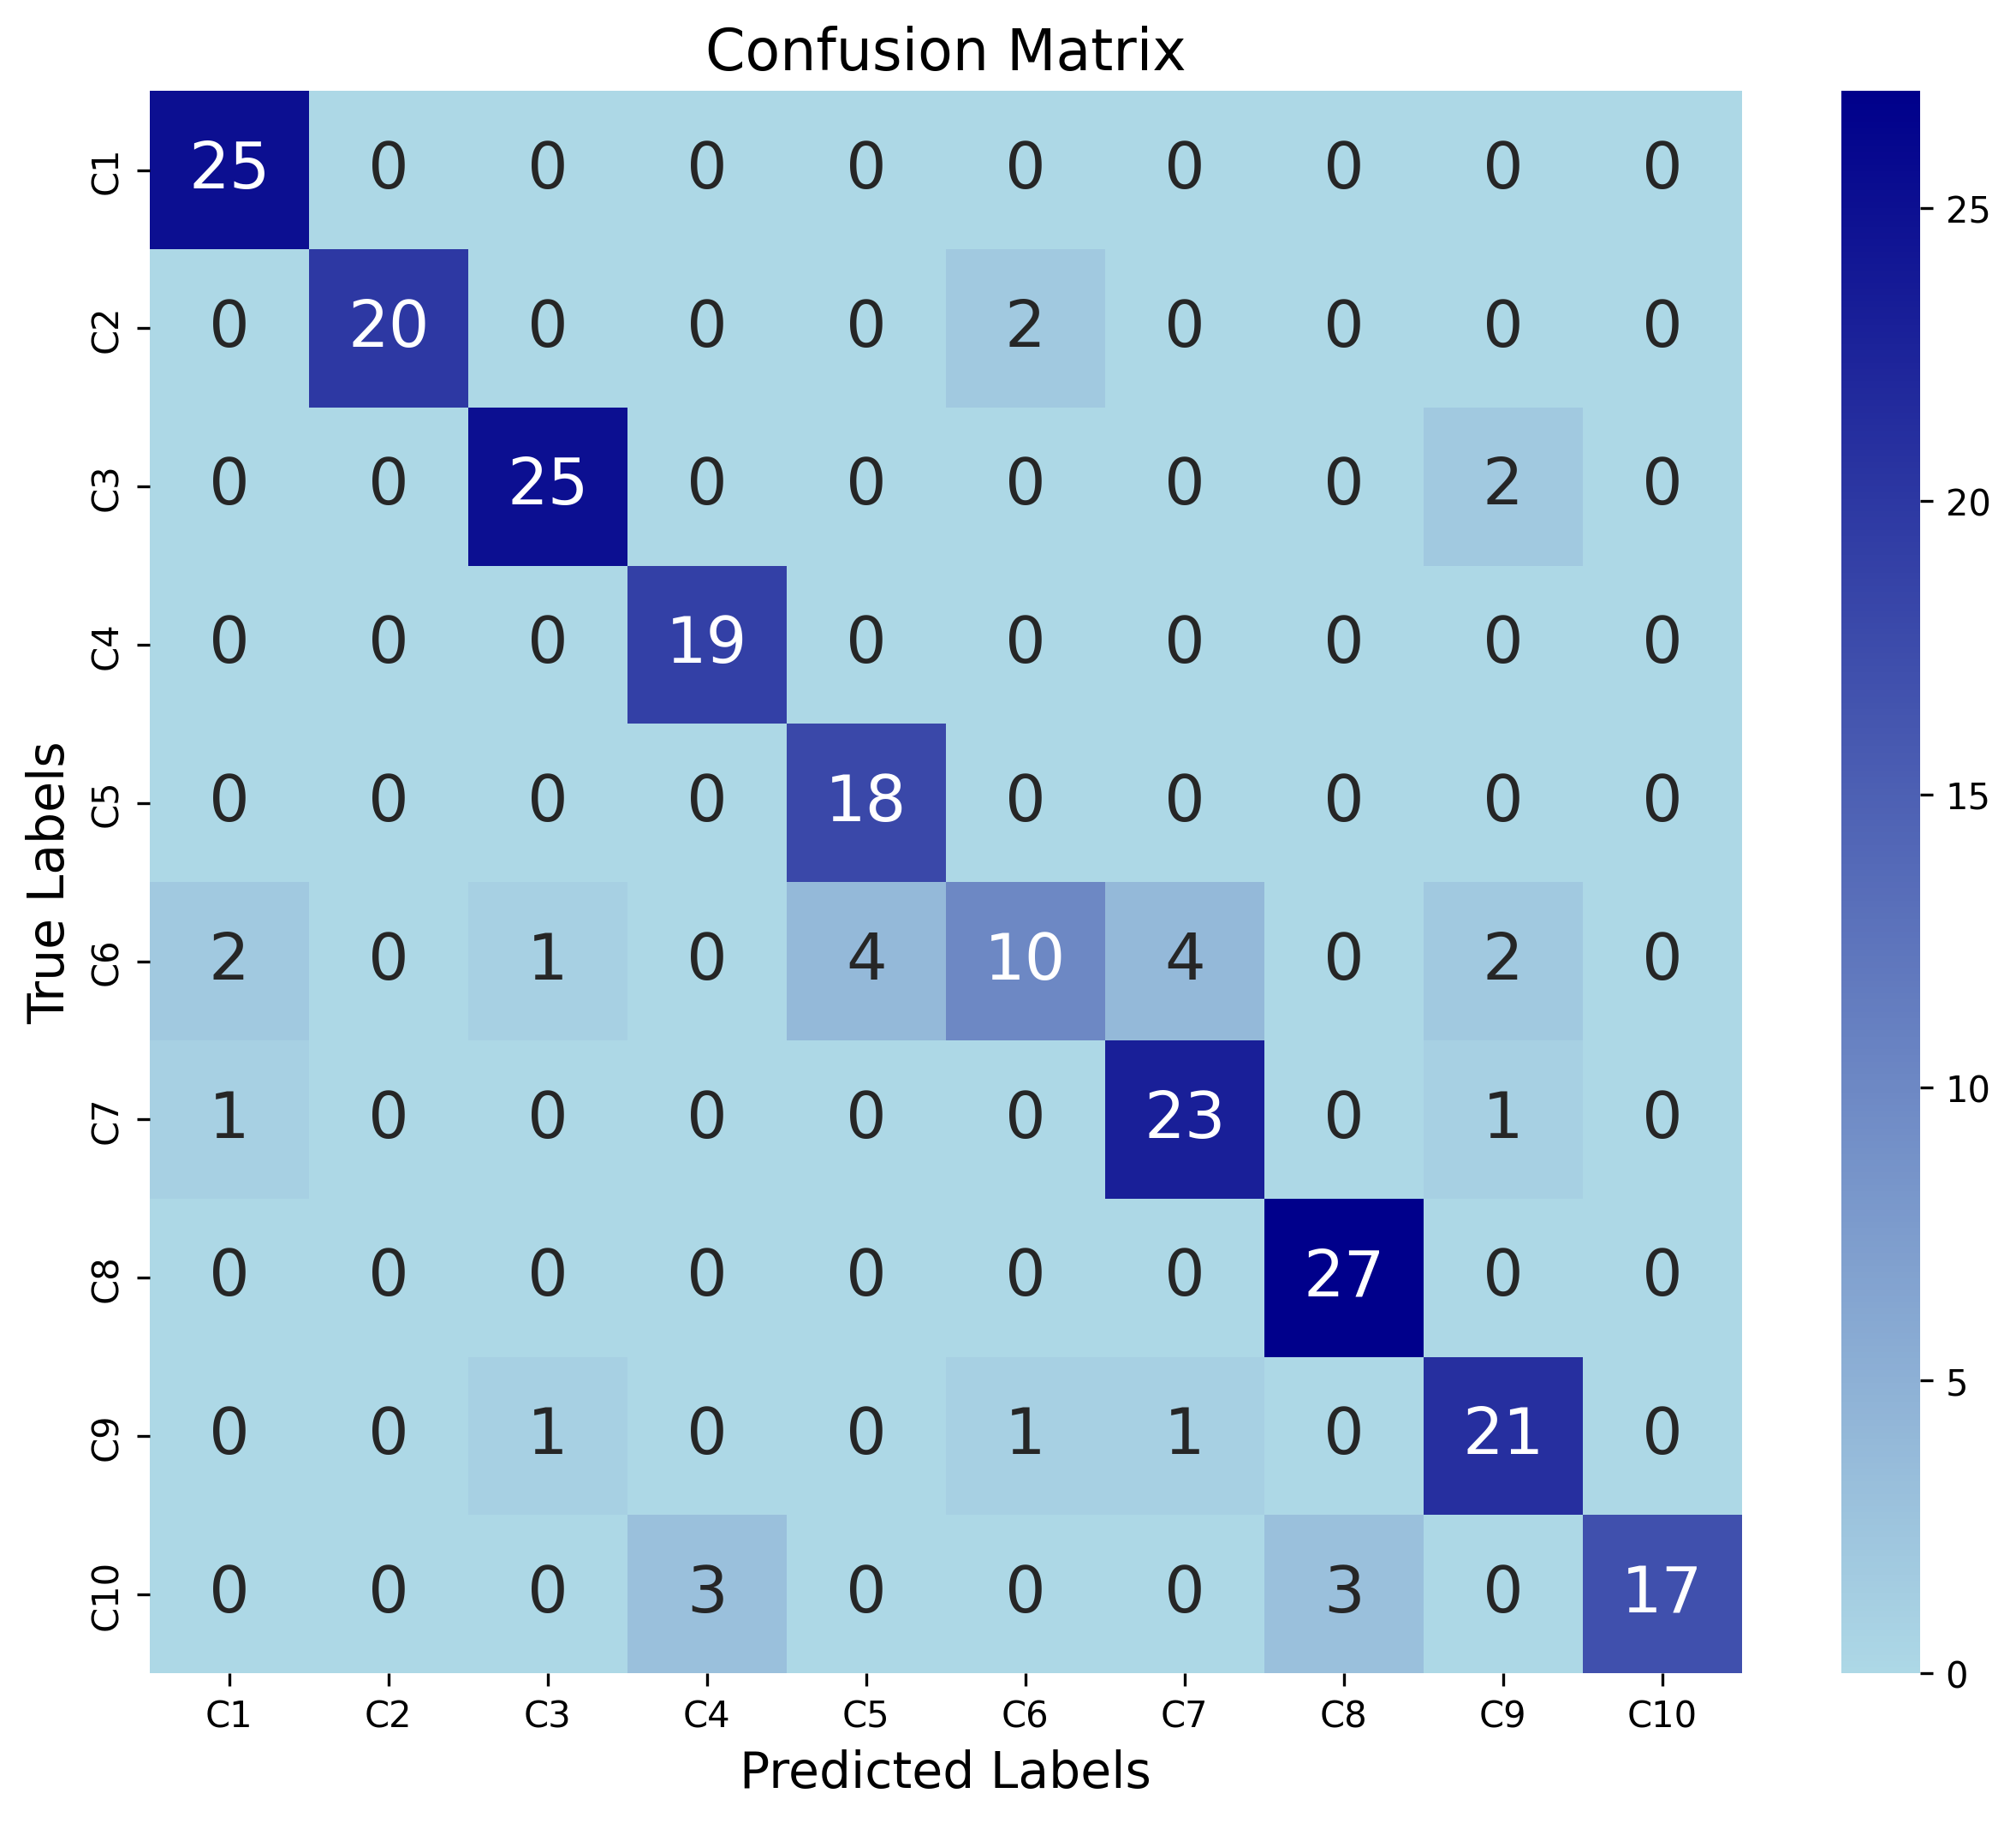


Final Test Performance: | Test Acc: 0.8798


In [1]:
#优化之后
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from joblib import load, dump
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# 设备配置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ... [保留原有数据集和模型定义代码不变] ...
# 1. 数据加载和预处理
class BearingDataset(Dataset):
    def __init__(self, dataframe):
        self.data = dataframe.iloc[:, :-1].values.astype(np.float32)
        self.labels = dataframe.iloc[:, -1].values.astype(np.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx], dtype=torch.float32).unsqueeze(-1)  # (seq_len, 1)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

# 加载保存的数据集
train_df = load('train_set')
val_df = load('val_set')
test_df = load('test_set')

# 创建DataLoader
batch_size = 32
train_dataset = BearingDataset(train_df)
val_dataset = BearingDataset(val_df)
test_dataset = BearingDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# 2. Transformer模型定义
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1024):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransformerClassifier(nn.Module):
    def __init__(self, input_dim=1, d_model=32, nhead=4, 
                 num_layers=3, dim_feedforward=128, num_classes=10):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_len, 1)
        x = self.embedding(x)  # (batch_size, seq_len, d_model)
        x = self.pos_encoder(x)
        x = x.permute(1, 0, 2)  # (seq_len, batch_size, d_model)
        output = self.transformer(x)  # (seq_len, batch_size, d_model)
        output = output.mean(dim=0)  # (batch_size, d_model)
        return self.fc(output)

# 3. 模型初始化
model = TransformerClassifier(
    d_model=64,
    nhead=2,
    num_layers=3,
    dim_feedforward=128,
    num_classes=10
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)

# 修改训练函数以返回准确率
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        total_loss += loss.item() * inputs.size(0)
    
    accuracy = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), accuracy

def evaluate(model, loader, criterion):  # 添加这个函数定义
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), accuracy  # 返回元组

# 训练循环（增加指标记录）
train_losses = []
train_accs = []
val_losses = []
val_accs = []

best_val_acc = 0.0
patience_counter = 0
patience = 10

for epoch in range(100):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    scheduler.step(val_acc)
    
    # 记录指标
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1:03d} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # 早停机制
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
        
        '''
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping!")
            break
        '''

# 保存训练指标
os.makedirs('./matfiles', exist_ok=True)
dump(train_losses, './matfiles/train_loss')
dump(train_accs, './matfiles/train_acc')
dump(val_losses, './matfiles/validate_loss')
dump(val_accs, './matfiles/validate_acc')

# 测试评估
model.load_state_dict(torch.load("best_model.pth"))
test_loss, test_acc = evaluate(model, test_loader, criterion)

# 获取完整预测结果
def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels

test_preds, test_labels = get_predictions(model, test_loader)

# 打印分类报告
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, digits=4))

# 混淆矩阵配置
label_mapping = {
    0: "C1",1: "C2",2: "C3",3: "C4",4: "C5",
    5: "C6",6: "C7",7: "C8",8: "C9",9: "C10",
}

colors = ["#ADD8E6", "#00008B"]
cmap = LinearSegmentedColormap.from_list("custom_blues", colors)

# 绘制混淆矩阵
confusion_mat = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(confusion_mat, 
            xticklabels=label_mapping.values(), 
            yticklabels=label_mapping.values(),
            annot=True,
            annot_kws={'size': 18}, 
            fmt='d', 
            cmap=cmap)
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.show()

print(f"\nFinal Test Performance: | Test Acc: {test_acc:.4f}")

   256
   256
131072
   512
524288
  1024
 10240
    10
______
667658


SGCNClassifier(
  (sgcn_layers): ModuleList(
    (0): SGConv(1, 256, K=1)
    (1): SGConv(256, 512, K=1)
    (2): SGConv(512, 1024, K=1)
  )
  (final_conv): SGConv(1024, 10, K=1)
)


Epoch:  1 train_Loss: 2.14822856 train_Accuracy:0.1795
Epoch:  1 val_Loss:1.84162484,  validate_Acc:0.1521
Epoch:  2 train_Loss: 1.60071875 train_Accuracy:0.4020
Epoch:  2 val_Loss:1.40940532,  validate_Acc:0.4250
Epoch:  3 train_Loss: 1.24333273 train_Accuracy:0.5870
Epoch:  3 val_Loss:1.11379767,  validate_Acc:0.4896
Epoch:  4 train_Loss: 1.00854624 train_Accuracy:0.6544
Epoch:  4 val_Loss:0.86773756,  validate_Acc:0.6958
Epoch:  5 train_Loss: 0.84801238 train_Accuracy:0.7500
Epoch:  5 val_Loss:0.82072715,  validate_Acc:0.7292
Epoch:  6 train_Loss: 0.73032728 train_Accuracy:0.7776
Epoch:  6 val_Loss:0.73525712,  validate_Acc:0.6708
Epoch:  7 train_Loss: 0.65371936 train_Accuracy:0.8033
Epoch:  7 val_Loss:0.57673585,  validate_Acc:0.7771
Epoch:  8 train_Loss: 0.59050362 train_Accuracy:0.8339
Epoch:  8 val_Loss:0.55949527,  validate_Acc:0.7833
Epoch:  9 train_Loss: 0.53861975 train_Accuracy:0.8615
Epoch:  9 val_Loss:0.45572439,  validate_Acc:0.8729
Epoch: 10 train_Loss: 0.51603589 trai

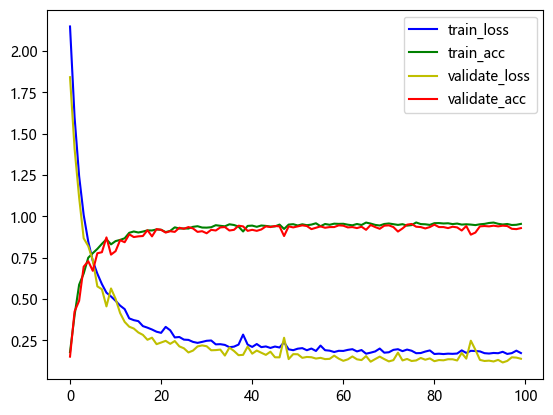

best_accuracy : 0.9541666666666667


              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        21
           1     0.9630    1.0000    0.9811        26
           2     1.0000    0.9615    0.9804        26
           3     1.0000    1.0000    1.0000        24
           4     1.0000    1.0000    1.0000        26
           5     0.9000    0.8182    0.8571        22
           6     0.7097    1.0000    0.8302        22
           7     1.0000    1.0000    1.0000        21
           8     0.9444    0.6800    0.7907        25
           9     1.0000    1.0000    1.0000        20

    accuracy                         0.9442       233
   macro avg     0.9517    0.9460    0.9440       233
weighted avg     0.9531    0.9442    0.9437       233



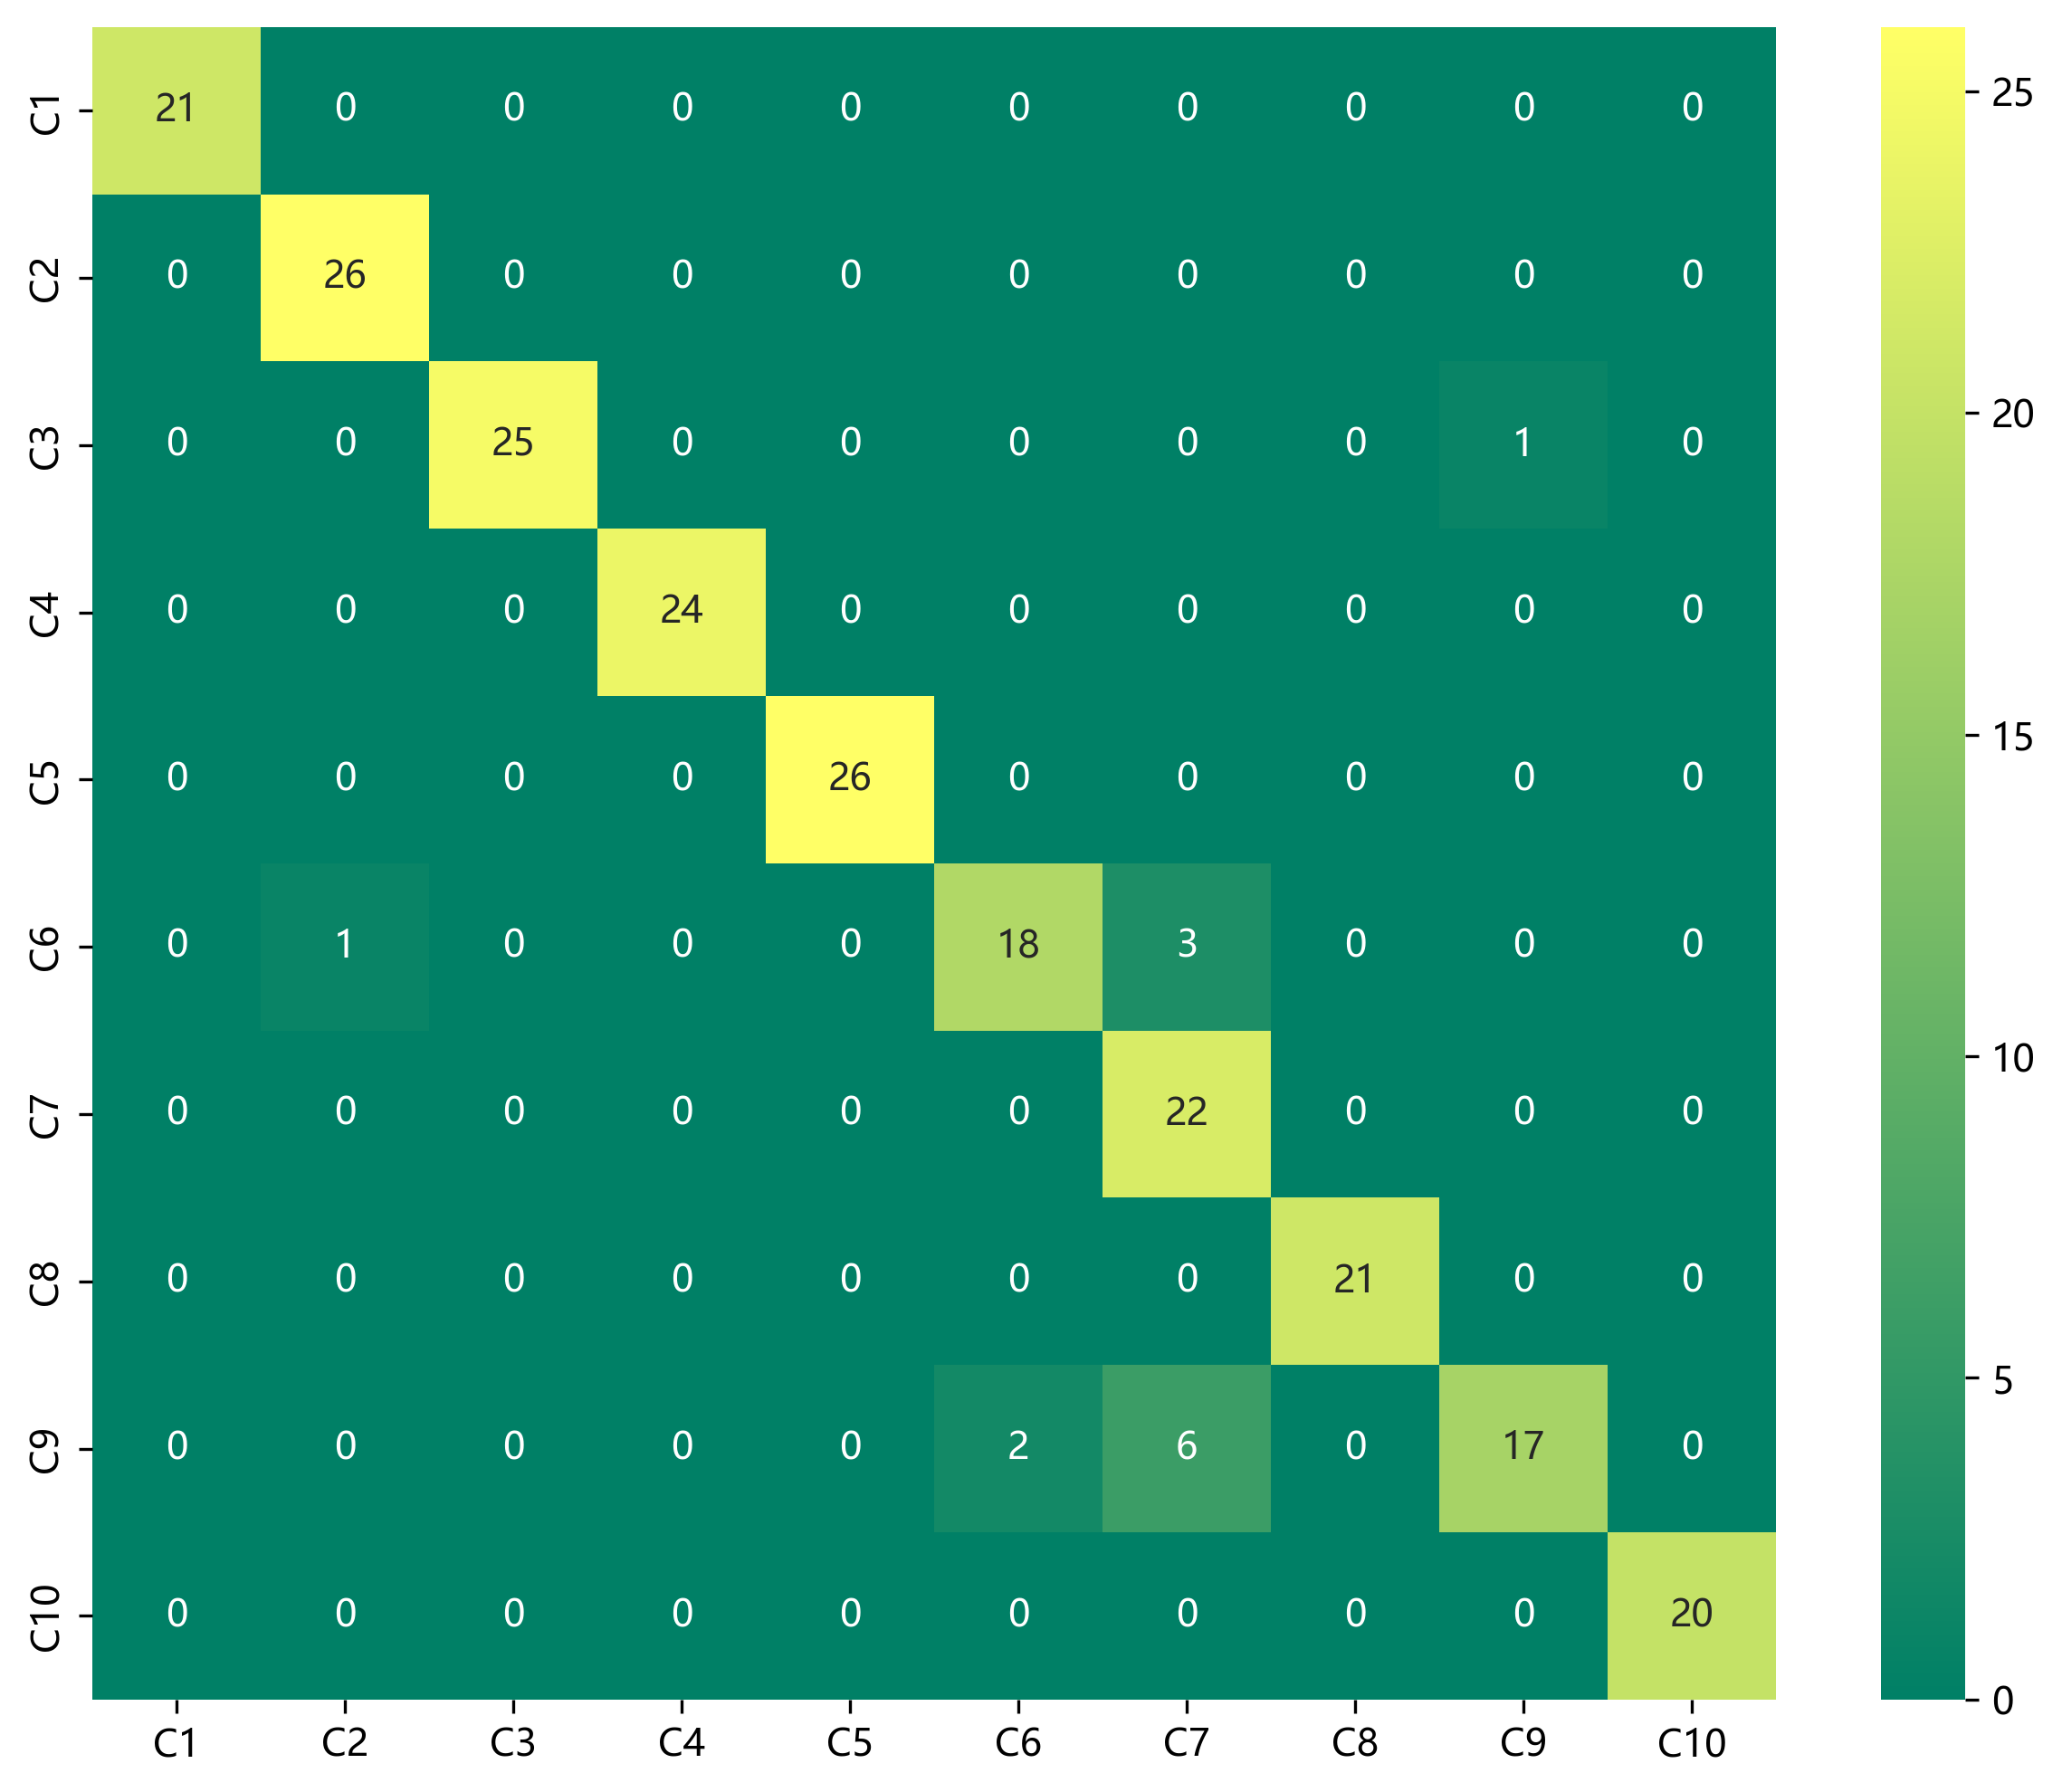

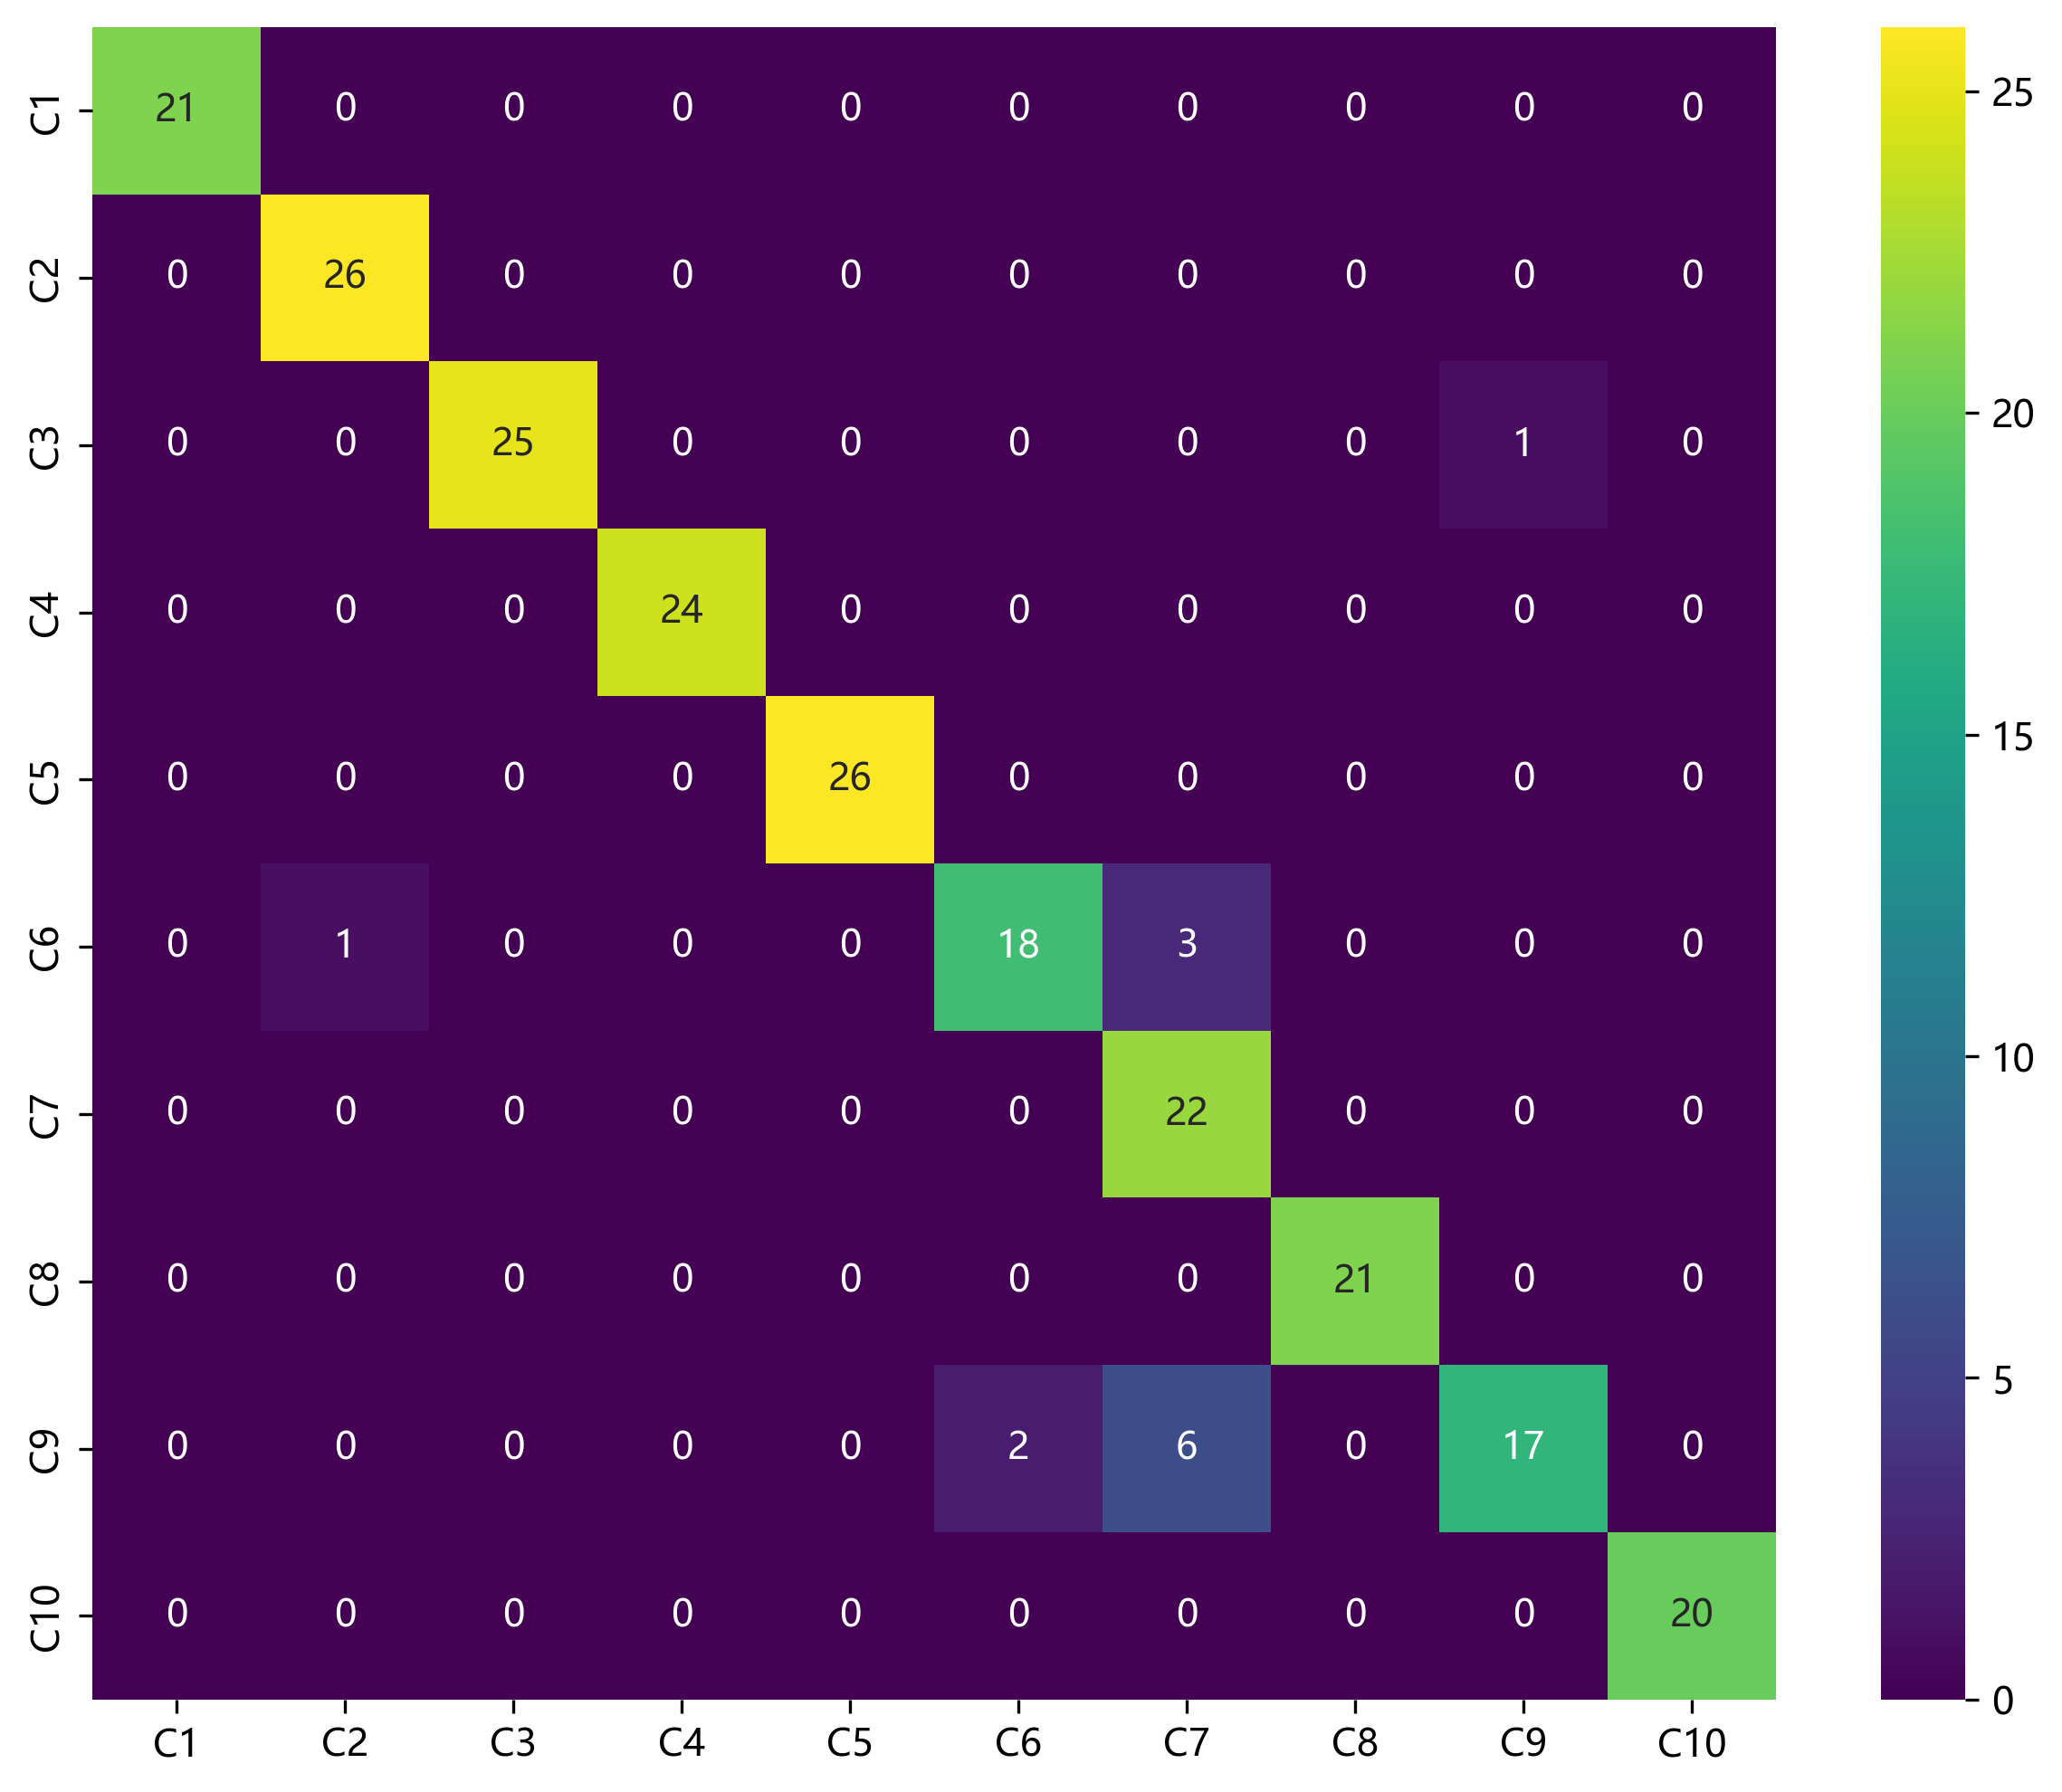